In [ ]:
### Remote Sensing Forest Change: Detecting Forest Conversion and its Biogeophysical Climate Effects and Ecological Effects in Bavaria
### Code for the Master's Thesis by Julia Jamula

## Time Series Analyses of NDVI, ET, Albedo, and LST in the Staatsforsten Study Areas

In [1]:
from io import BytesIO
import datetime
import ee
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
from scipy.stats import linregress
import pandas as pd

PROJECT_NAME='xxx'
ee.Initialize(project=PROJECT_NAME)

ASSET="xxx" # insert path of GEE asset
bayern = ee.FeatureCollection(ASSET)
ROI = ee.FeatureCollection(ASSET)

# Regionen
FGB = ee.FeatureCollection(ASSET)
RGB = ee.FeatureCollection(ASSET)
MUC = ee.FeatureCollection(ASSET)



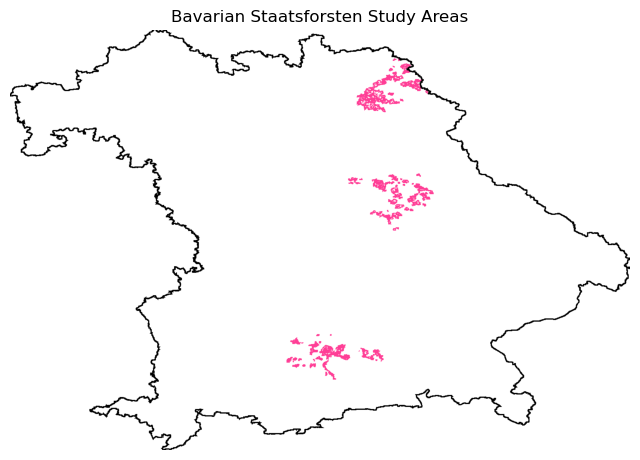

In [2]:
# Staatsforsten areas within Bavaria


base = ee.Image.constant(1).visualize(
    palette=["FFFFFF"],  # weißer Hintergrund
    opacity=1
)

# Regions in pink
roi_img = ee.Image().paint(ROI, 1, 2).visualize(palette=["FF3E96"])  


# Bavaria delineation
bayern_outline = ee.Image().paint(bayern, 0, 3).visualize(palette=["000000"])

# Ebenen übereinander blenden
final_img = base.blend(roi_img).blend(bayern_outline)


region = bayern.geometry().bounds().getInfo()["coordinates"]

# Thumb
url = final_img.getThumbURL({
    "region": region,
    "dimensions": 1500,
    "format": "png"
})

# Plot
response = requests.get(url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Bavarian Staatsforsten Study Areas", fontsize=12)
plt.show()


In [2]:

def get_ndvi(img):
    return img.select("NDVI").multiply(0.0001).copyProperties(img, ["system:time_start"])

def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask)
NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").map(maskNDVI).map(get_ndvi)

modis_proj = NDVI.first().projection()


Forest conversion area Staatsforsten (2014 to 2024): 166.43 km²


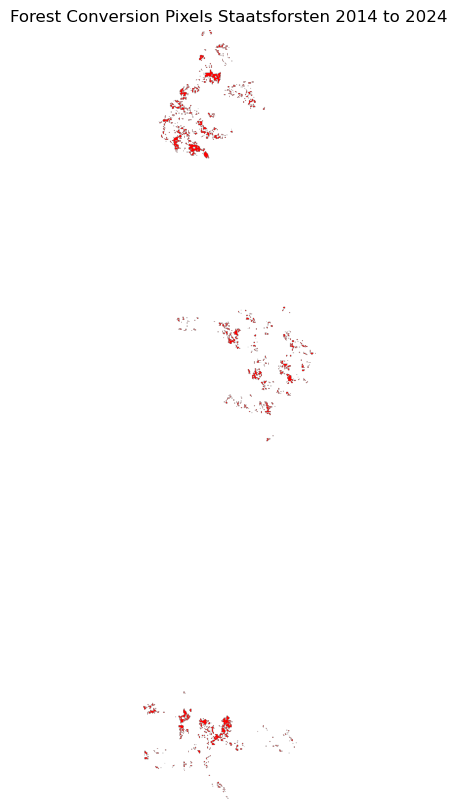

In [3]:
### Forest Conversion 2014 - 2024



def season_mean(year, months, NDVI):
        imgs = []
        for m in months:
            coll = NDVI.filterDate(
                ee.Date.fromYMD(year, m, 1),
                ee.Date.fromYMD(year, m, 1).advance(1, "month")
            )
            imgs.append(coll.mean())
        return ee.ImageCollection(imgs).mean()


def classify_forest(year):

    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .map(maskNDVI)
        .map(get_ndvi)
    )

    winter = season_mean(year, [1,2,3], NDVI)
    summer = season_mean(year, [5,6,7], NDVI)

    diff = summer.subtract(winter)

    class_img = (
        ee.Image(0)
        .where(diff.lte(0.165), 1)
        .where(diff.gt(0.165), 2)
        .rename("class")
        .clip(ROI)
        .reproject(modis_proj)
    )

    return class_img

class_2014 = classify_forest(2014)
class_2024 = classify_forest(2024)





# Needleleaf 2014 → Broadleaf/mixed 2024
conversion = (
    class_2014.eq(1)
    .And(class_2024.eq(2))
).selfMask().rename("conversion")


# Area
conversion_km2 = (
    conversion
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ROI.geometry(),
        scale = modis_proj.nominalScale(),
        crs=modis_proj.crs(),
        maxPixels=1e13
    )
    .get("conversion")
    .getInfo()
) / 1e6
print(f"Forest conversion area Staatsforsten (2014 to 2024): {conversion_km2:.2f} km²")

# Plot
thumb_url = conversion.visualize(
    palette=["red"],
    min=0,
    max=1
).getThumbURL({
    "region": ROI.geometry(),
    "dimensions": 2000,
    "crs": modis_proj.crs(),
    "format": "png"
})

response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title("Forest Conversion Pixels Staatsforsten 2014 to 2024")
plt.axis("off")
plt.show()


Stable Needleleaf area Staatsforsten (2014 to 2024): 427.42 km²


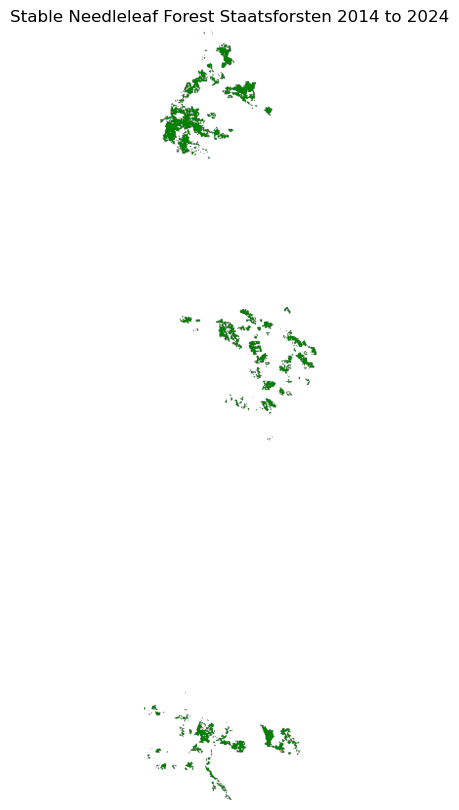

In [4]:
### Stable Needleleaf 2014 - 2024



def season_mean(year, months, NDVI):
        imgs = []
        for m in months:
            coll = NDVI.filterDate(
                ee.Date.fromYMD(year, m, 1),
                ee.Date.fromYMD(year, m, 1).advance(1, "month")
            )
            imgs.append(coll.mean())
        return ee.ImageCollection(imgs).mean()


def classify_forest(year):

    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .map(maskNDVI)
        .map(get_ndvi)
    )

    winter = season_mean(year, [1,2,3], NDVI)
    summer = season_mean(year, [5,6,7], NDVI)

    diff = summer.subtract(winter)

    class_img = (
        ee.Image(0)
        .where(diff.lte(0.165), 1)
        .where(diff.gt(0.165), 2)
        .rename("class")
        .clip(ROI)
        .reproject(modis_proj)
    )

    return class_img



class_2014 = classify_forest(2014)
class_2024 = classify_forest(2024)


# Needle 2014 -> Needle 2024
needle_stable = (
    class_2014.eq(1)
    .And(class_2024.eq(1))
).selfMask().rename("needle")


# Area
needle_km2 = (
    needle_stable
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ROI.geometry(),
        scale = modis_proj.nominalScale(),
        crs=modis_proj.crs(),
        maxPixels=1e13
    )
    .get("needle")
    .getInfo()
) / 1e6
print(f"Stable Needleleaf area Staatsforsten (2014 to 2024): {needle_km2:.2f} km²")

# Plot
thumb_url = needle_stable.visualize(
    palette=["green"],
    min=0,
    max=1
).getThumbURL({
    "region": ROI.geometry(),
    "dimensions": 2000,
    "crs": modis_proj.crs(),
    "format": "png"
})

response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title("Stable Needleleaf Forest Staatsforsten 2014 to 2024")
plt.axis("off")
plt.show()



Stable Broadleaf/ Mixed area Staatsforsten (2014 to 2024): 65.98 km²


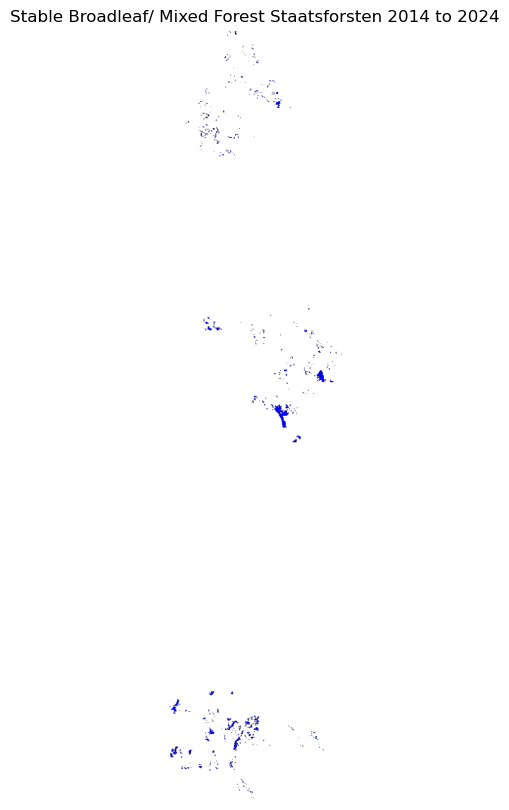

In [5]:
### Stable Broadleaf/mixed 2014 - 2024



def season_mean(year, months, NDVI):
        imgs = []
        for m in months:
            coll = NDVI.filterDate(
                ee.Date.fromYMD(year, m, 1),
                ee.Date.fromYMD(year, m, 1).advance(1, "month")
            )
            imgs.append(coll.mean())
        return ee.ImageCollection(imgs).mean()


def classify_forest(year):

    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .map(maskNDVI)
        .map(get_ndvi)
    )

    winter = season_mean(year, [1,2,3], NDVI)
    summer = season_mean(year, [5,6,7], NDVI)

    diff = summer.subtract(winter)

    class_img = (
        ee.Image(0)
        .where(diff.lte(0.165), 1)
        .where(diff.gt(0.165), 2)
        .rename("class")
        .clip(ROI)
        .reproject(modis_proj)
    )

    return class_img



class_2014 = classify_forest(2014)
class_2024 = classify_forest(2024)


# Broadleaf/mixed 2014 and broadleaf/mixed 2024
broadleaf_stable = (
    class_2014.eq(2)
    .And(class_2024.eq(2))
).selfMask().rename("broadl")


# Fläche
broadleaf_km2 = (
    broadleaf_stable
    .multiply(ee.Image.pixelArea())
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ROI.geometry(),
        scale = modis_proj.nominalScale(),
        crs=modis_proj.crs(),
        maxPixels=1e13
    )
    .get("broadl")
    .getInfo()
) / 1e6
print(f"Stable Broadleaf/ Mixed area Staatsforsten (2014 to 2024): {broadleaf_km2:.2f} km²")

# Plot
thumb_url = broadleaf_stable.visualize(
    palette=["blue"],
    min=0,
    max=1
).getThumbURL({
    "region": ROI.geometry(),
    "dimensions": 2000,
    "crs": modis_proj.crs(),
    "format": "png"
})

response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.title("Stable Broadleaf/ Mixed Forest Staatsforsten 2014 to 2024")
plt.axis("off")
plt.show()





In [10]:
def maskNDVI(image):
    qc = image.select('DetailedQA')
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask)
NDVI = ee.ImageCollection("MODIS/061/MOD13Q1").map(maskNDVI).map(maskNDVI)

modis_proj = NDVI.first().projection()


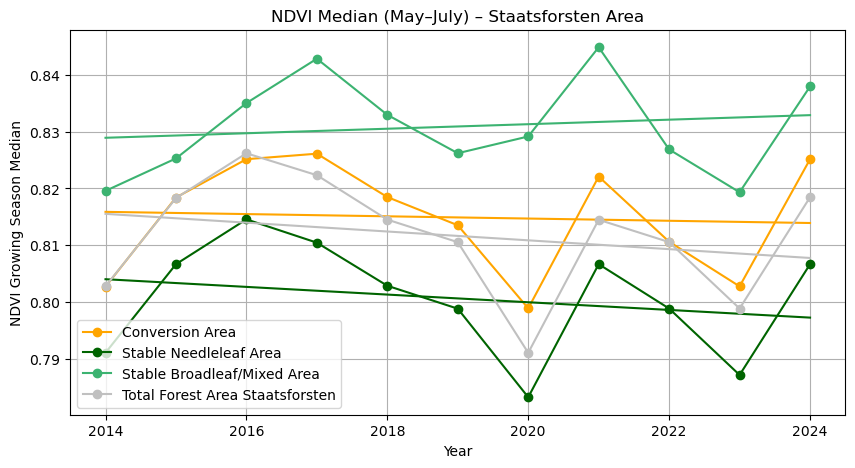


Conversion
Slope: -0.000197
Intercept: 1.212123
R²: 0.0043
p-value: 0.847992
Standard Error: 0.000997

Needleleaf Stable
Slope: -0.000677
Intercept: 2.167940
R²: 0.0510
p-value: 0.504446
Standard Error: 0.000974

Broadleaf/Mixed Stable
Slope: 0.000399
Intercept: 0.025048
R²: 0.0235
p-value: 0.652818
Standard Error: 0.000858

Total Forest Bavaria
Slope: -0.000778
Intercept: 2.382198
R²: 0.0602
p-value: 0.466943
Standard Error: 0.001024


In [11]:
### NDVI growing season medians of different forest structural classes 



NDVI_conversion = NDVI.map(lambda img: img.updateMask(conversion))
NDVI_needle = NDVI.map(lambda img: img.updateMask(needle_stable))
NDVI_broadleaf = NDVI.map(lambda img: img.updateMask(broadleaf_stable))
NDVI_staatsforsten= NDVI.map(lambda img: img.clip(ROI))  # Hier reicht clip ROI, keine extra forest maske nötig, weil ROI sowieso nur forest area ist


years = list(range(2014, 2025))


def values(NDVI):
    ndvi_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        value = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        ndvi_values.append(value)
    return ndvi_values


conversion_values = values(NDVI_conversion)
needle_values = values(NDVI_needle)
broadleaf_values = values(NDVI_broadleaf)
staatsforsten_values = values(NDVI_staatsforsten)


# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(staatsforsten_values)


slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, staatsforsten_values, marker="o", color="silver", label="Total Forest Area Staatsforsten")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("NDVI Growing Season Median")
plt.title("NDVI Median (May–July) – Staatsforsten Area")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\n{name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")


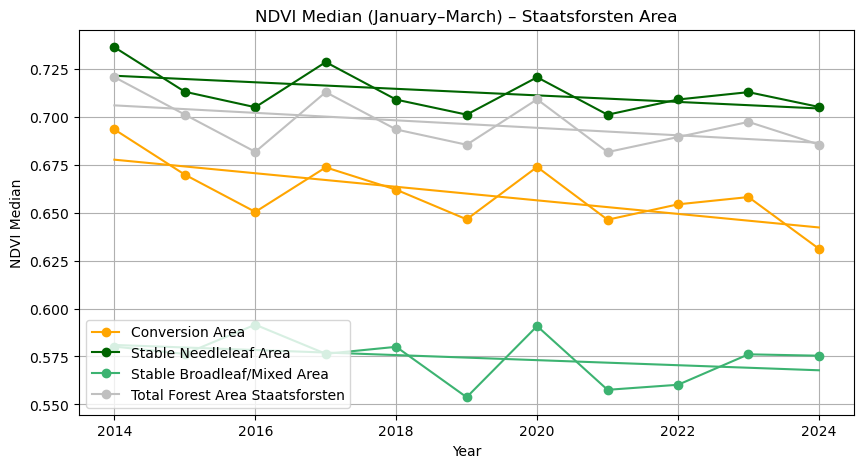


Conversion
Slope: -0.003535
Intercept: 7.796648
R²: 0.4705
p-value: 0.019787
Standard Error: 0.001250

Needleleaf Stable
Slope: -0.001706
Intercept: 4.157992
R²: 0.2498
p-value: 0.117487
Standard Error: 0.000986

Broadleaf/Mixed Stable
Slope: -0.001321
Intercept: 3.242002
R²: 0.1238
p-value: 0.288530
Standard Error: 0.001171

Total Forest Bavaria
Slope: -0.001951
Intercept: 4.636137
R²: 0.2359
p-value: 0.129850
Standard Error: 0.001171


In [12]:
### NDVI winter season medians of different forest structural classes



NDVI_conversion = NDVI.map(lambda img: img.updateMask(conversion))
NDVI_needle = NDVI.map(lambda img: img.updateMask(needle_stable))
NDVI_broadleaf = NDVI.map(lambda img: img.updateMask(broadleaf_stable))
NDVI_staatsforsten= NDVI.map(lambda img: img.clip(ROI))  # Hier reicht clip ROI, keine extra forest maske nötig, weil ROI sowieso nur forest area ist


years = list(range(2014, 2025))


def values(NDVI):
    ndvi_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        value = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        ndvi_values.append(value)
    return ndvi_values


conversion_values = values(NDVI_conversion)
needle_values = values(NDVI_needle)
broadleaf_values = values(NDVI_broadleaf)
staatsforsten_values = values(NDVI_staatsforsten)


# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(staatsforsten_values)


slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, staatsforsten_values, marker="o", color="silver", label="Total Forest Area Staatsforsten")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("NDVI Median")
plt.title("NDVI Median (January–March) – Staatsforsten Area")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\n{name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")


Region Fichtelgebirge

Conversion
Slope:      -0.001509
Intercept:  3.857116
R²:         0.1320
p-value:    0.272062
Std Error:  0.001290

Needleleaf Stable
Slope:      -0.001616
Intercept:  4.062480
R²:         0.1486
p-value:    0.241688
Std Error:  0.001290

Broadleaf/Mixed Stable
Slope:      -0.001342
Intercept:  3.522815
R²:         0.0968
p-value:    0.351663
Std Error:  0.001366

Total Forest
Slope:      -0.001563
Intercept:  3.957613
R²:         0.1473
p-value:    0.243926
Std Error:  0.001253

Region Regensburg

Conversion
Slope:      0.001369
Intercept:  -1.948538
R²:         0.1235
p-value:    0.289243
Std Error:  0.001215

Needleleaf Stable
Slope:      0.000405
Intercept:  -0.028104
R²:         0.0119
p-value:    0.749671
Std Error:  0.001230

Broadleaf/Mixed Stable
Slope:      0.001743
Intercept:  -2.664838
R²:         0.3106
p-value:    0.074864
Std Error:  0.000866

Total Forest
Slope:      0.000786
Intercept:  -0.788614
R²:         0.0466
p-value:    0.523665
Std Error

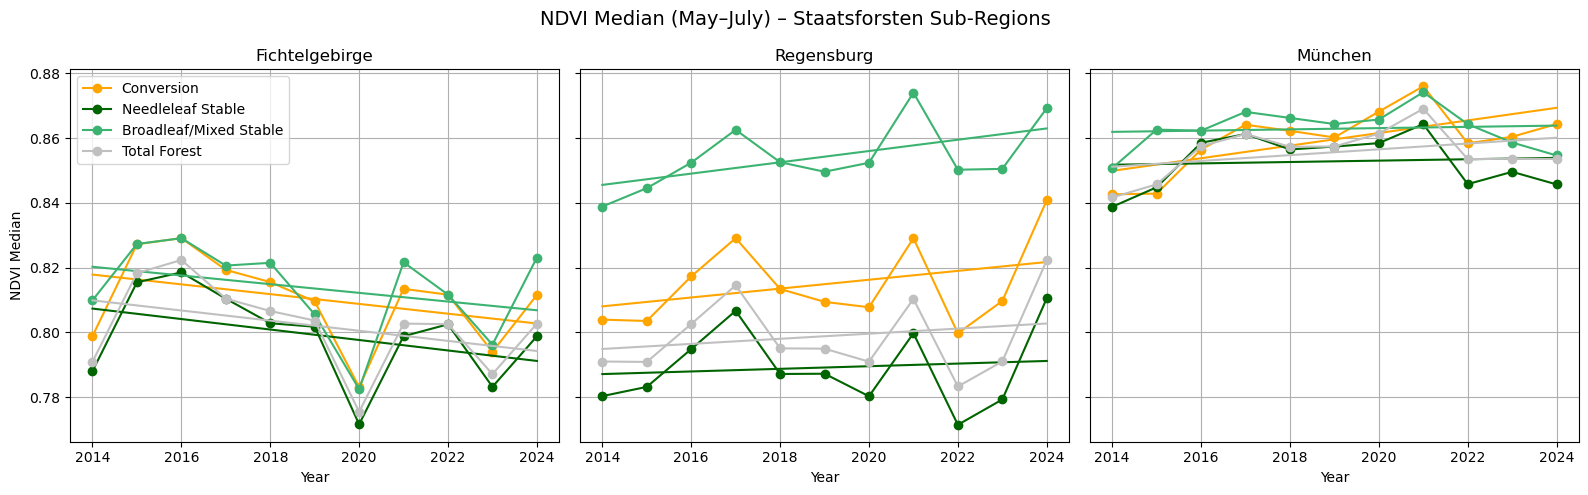

In [13]:
# NDVI growing season medians of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))




def ndvi_timeseries(region, klasse):
    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .filterBounds(region)
        .map(maskNDVI)
        .map(lambda img: img.updateMask(klasse)) 
        .map(lambda img: img.clip(region))       
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        val = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def ndvi_timeseries_total(region): # staatsforsten total hat keine klasse
    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .map(maskNDVI)
        .map(lambda img: img.clip(region))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        val = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        values.append(val)

    return np.array(values)

def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

forest_classes = [
    ("Conversion", conversion),
    ("Needleleaf Stable", needle_stable),
    ("Broadleaf/Mixed Stable", broadleaf_stable),
    ("Total Forest", None),  # eineger Fall, hat keine klasse
]

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (region_name, region) in zip(axes, regions.items()):

    print(f"\nRegion {region_name}")

    results = {}

    # Timeseries
    series = {
        "Conversion": ndvi_timeseries(region, conversion),
        "Needleleaf Stable": ndvi_timeseries(region, needle_stable),
        "Broadleaf/Mixed Stable": ndvi_timeseries(region, broadleaf_stable),
        "Total Forest": ndvi_timeseries_total(region),
    }

    t = np.array(years)

    # Regression and Plot
    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
        "Total Forest": "silver",
    }

    for name, vals in series.items():

        # Regression
        stats = regression_stats(t, vals)
        results[name] = stats

        # Trendline
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print(f"\n{name}")
        print(f"Slope:      {stats['slope']:.6f}")
        print(f"Intercept:  {stats['intercept']:.6f}")
        print(f"R²:         {stats['r2']:.4f}")
        print(f"p-value:    {stats['p']:.6f}")
        print(f"Std Error:  {stats['std_err']:.6f}")

    ax.set_title(region_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("NDVI Median")
axes[0].legend(loc="upper left")

fig.suptitle("NDVI Median (May–July) – Staatsforsten Sub-Regions", fontsize=14)
plt.tight_layout()
plt.show()

 REGION Fichtelgebirge

Conversion
Slope:        0.000054
Intercept:    -0.100498
R²:           0.0172
p-value:      0.700990
Std. Error:   0.000136

Needleleaf Stable
Slope:        -0.000053
Intercept:    0.104867
R²:           0.0136
p-value:      0.732661
Std. Error:   0.000151

Broadleaf/Mixed Stable
Slope:        0.000221
Intercept:    -0.434798
R²:           0.0151
p-value:      0.719047
Std. Error:   0.000595
 REGION Regensburg

Conversion
Slope:        0.000582
Intercept:    -1.159925
R²:           0.6898
p-value:      0.001546
Std. Error:   0.000130

Needleleaf Stable
Slope:        -0.000381
Intercept:    0.760509
R²:           0.4733
p-value:      0.019281
Std. Error:   0.000134

Broadleaf/Mixed Stable
Slope:        0.000957
Intercept:    -1.876224
R²:           0.2118
p-value:      0.154339
Std. Error:   0.000615
 REGION München

Conversion
Slope:        0.001050
Intercept:    -2.115557
R²:           0.7763
p-value:      0.000339
Std. Error:   0.000188

Needleleaf Stable
Slo

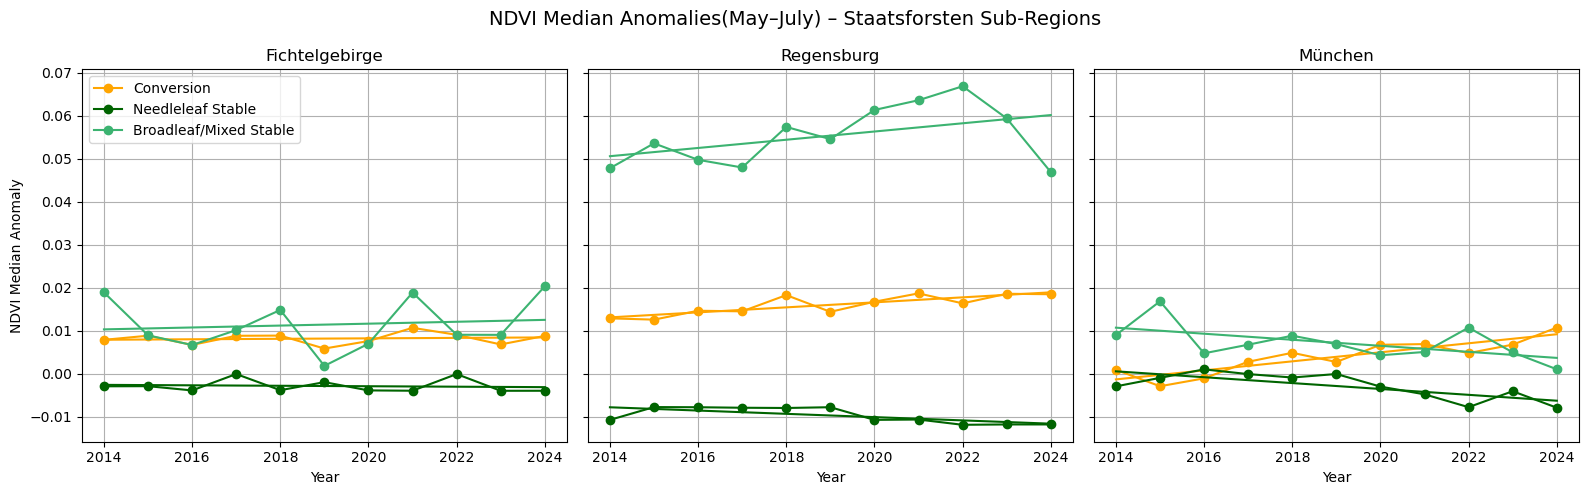

In [14]:
# NDVI growing season anomalies of different forest structural classes - Regions split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def ndvi_timeseries(region, klasse):
    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .filterBounds(region)
        .map(maskNDVI)
        .map(lambda img: img.updateMask(klasse)) 
        .map(lambda img: img.clip(region))       
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        val = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def ndvi_timeseries_total(region): # staatsforsten total hat keine klasse
    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .map(maskNDVI)
        .map(lambda img: img.clip(region))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        val = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (reg_name, region) in zip(axes, regions.items()):
    
    print(f" REGION {reg_name}")

    
    # Timeseries
    conv  = ndvi_timeseries(region, conversion)
    need  = ndvi_timeseries(region, needle_stable)
    broad = ndvi_timeseries(region, broadleaf_stable)
    total = ndvi_timeseries_total(region)

    # Anomalies
    conv_delta  = conv  - total
    need_delta  = need  - total
    broad_delta = broad - total

    t = np.array(years)

    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
    }

    # Names
    anomaly_series = {
        "Conversion": conv_delta,
        "Needleleaf Stable": need_delta,
        "Broadleaf/Mixed Stable": broad_delta,
    }

    for name, vals in anomaly_series.items():

        stats = regression_stats(t, vals)
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print(f"\n{name}")
        print(f"Slope:        {stats['slope']:.6f}")
        print(f"Intercept:    {stats['intercept']:.6f}")
        print(f"R²:           {stats['r2']:.4f}")
        print(f"p-value:      {stats['p']:.6f}")
        print(f"Std. Error:   {stats['std_err']:.6f}")

    ax.set_title(reg_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("NDVI Median Anomaly")
axes[0].legend(loc="upper left")

fig.suptitle("NDVI Median Anomalies(May–July) – Staatsforsten Sub-Regions", fontsize=14)

plt.tight_layout()
plt.show()


Region Fichtelgebirge

Conversion
Slope:      -0.003659
Intercept:  8.076290
R²:         0.1499
p-value:    0.239439
Std Error:  0.002905

Needleleaf Stable
Slope:      -0.000722
Intercept:  2.178731
R²:         0.0102
p-value:    0.767122
Std Error:  0.002364

Broadleaf/Mixed Stable
Slope:      -0.001442
Intercept:  3.496930
R²:         0.0366
p-value:    0.573043
Std Error:  0.002466

Total Forest
Slope:      -0.001048
Intercept:  2.825566
R²:         0.0181
p-value:    0.693194
Std Error:  0.002572

Region Regensburg

Conversion
Slope:      -0.005257
Intercept:  11.281084
R²:         0.7928
p-value:    0.000238
Std Error:  0.000896

Needleleaf Stable
Slope:      -0.003482
Intercept:  7.740268
R²:         0.6151
p-value:    0.004269
Std Error:  0.000918

Broadleaf/Mixed Stable
Slope:      -0.003636
Intercept:  7.927967
R²:         0.4411
p-value:    0.025822
Std Error:  0.001364

Total Forest
Slope:      -0.003588
Intercept:  7.931060
R²:         0.6369
p-value:    0.003238
Std Erro

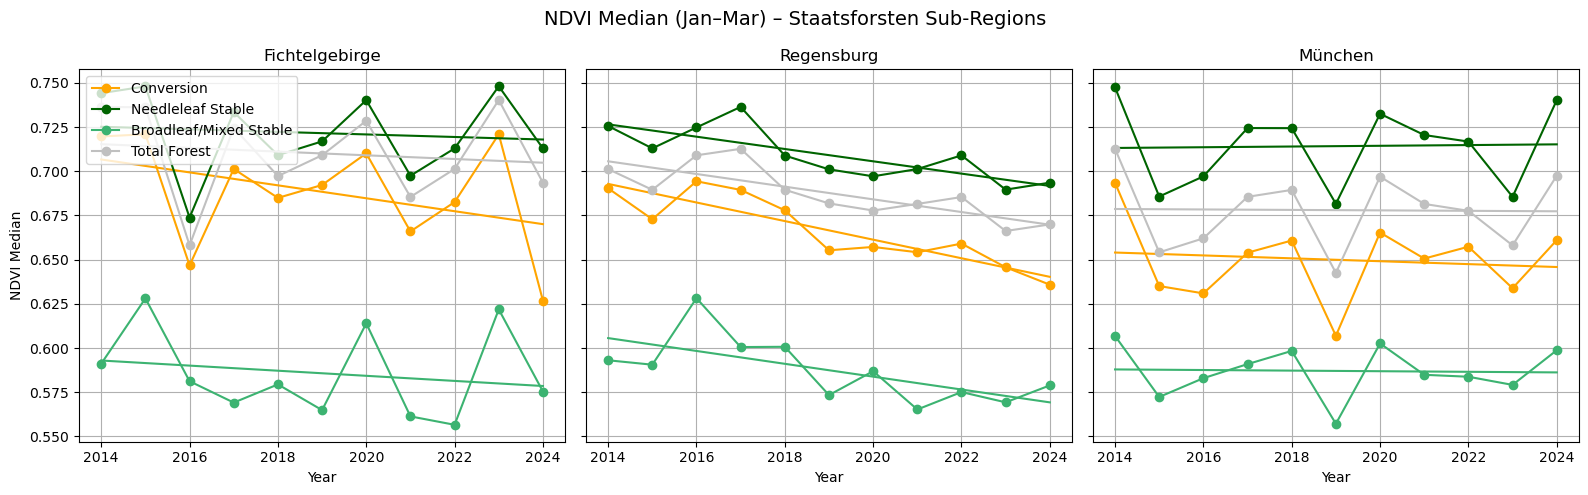

In [15]:
# NDVI winter season medians of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def ndvi_timeseries(region, klasse):
    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .filterBounds(region)
        .map(maskNDVI)
        .map(lambda img: img.updateMask(klasse)) 
        .map(lambda img: img.clip(region))       
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        val = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def ndvi_timeseries_total(region): # staatsforsten total hat keine klasse
    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .map(maskNDVI)
        .map(lambda img: img.clip(region))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        val = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

forest_classes = [
    ("Conversion", conversion),
    ("Needleleaf Stable", needle_stable),
    ("Broadleaf/Mixed Stable", broadleaf_stable),
    ("Total Forest", None),  # eineger Fall, hat keine klasse
]

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (region_name, region) in zip(axes, regions.items()):

    print(f"\nRegion {region_name}")

    results = {}

    # Timeseries
    series = {
        "Conversion": ndvi_timeseries(region, conversion),
        "Needleleaf Stable": ndvi_timeseries(region, needle_stable),
        "Broadleaf/Mixed Stable": ndvi_timeseries(region, broadleaf_stable),
        "Total Forest": ndvi_timeseries_total(region),
    }

    t = np.array(years)

    # Regression and Plot
    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
        "Total Forest": "silver",
    }

    for name, vals in series.items():

        # Regression
        stats = regression_stats(t, vals)
        results[name] = stats

        # Trendline
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print(f"\n{name}")
        print(f"Slope:      {stats['slope']:.6f}")
        print(f"Intercept:  {stats['intercept']:.6f}")
        print(f"R²:         {stats['r2']:.4f}")
        print(f"p-value:    {stats['p']:.6f}")
        print(f"Std Error:  {stats['std_err']:.6f}")

    ax.set_title(region_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("NDVI Median")
axes[0].legend(loc="upper left")

fig.suptitle("NDVI Median (Jan–Mar) – Staatsforsten Sub-Regions", fontsize=14)

plt.tight_layout()
plt.show()

   
 REGION Fichtelgebirge

Conversion
Slope:        -0.002611
Intercept:    5.250724
R²:           0.3202
p-value:      0.069600
Std. Error:   0.001268

Needleleaf Stable
Slope:        0.000326
Intercept:    -0.646836
R²:           0.0903
p-value:      0.369296
Std. Error:   0.000345

Broadleaf/Mixed Stable
Slope:        -0.000394
Intercept:    0.671363
R²:           0.0035
p-value:      0.863726
Std. Error:   0.002232
   
 REGION Regensburg

Conversion
Slope:        -0.001670
Intercept:    3.350024
R²:           0.5838
p-value:      0.006185
Std. Error:   0.000470

Needleleaf Stable
Slope:        0.000105
Intercept:    -0.190792
R²:           0.0153
p-value:      0.717096
Std. Error:   0.000281

Broadleaf/Mixed Stable
Slope:        -0.000048
Intercept:    -0.003093
R²:           0.0002
p-value:      0.967680
Std. Error:   0.001155
   
 REGION München

Conversion
Slope:        -0.000691
Intercept:    1.366390
R²:           0.1299
p-value:      0.276219
Std. Error:   0.000596

Needlele

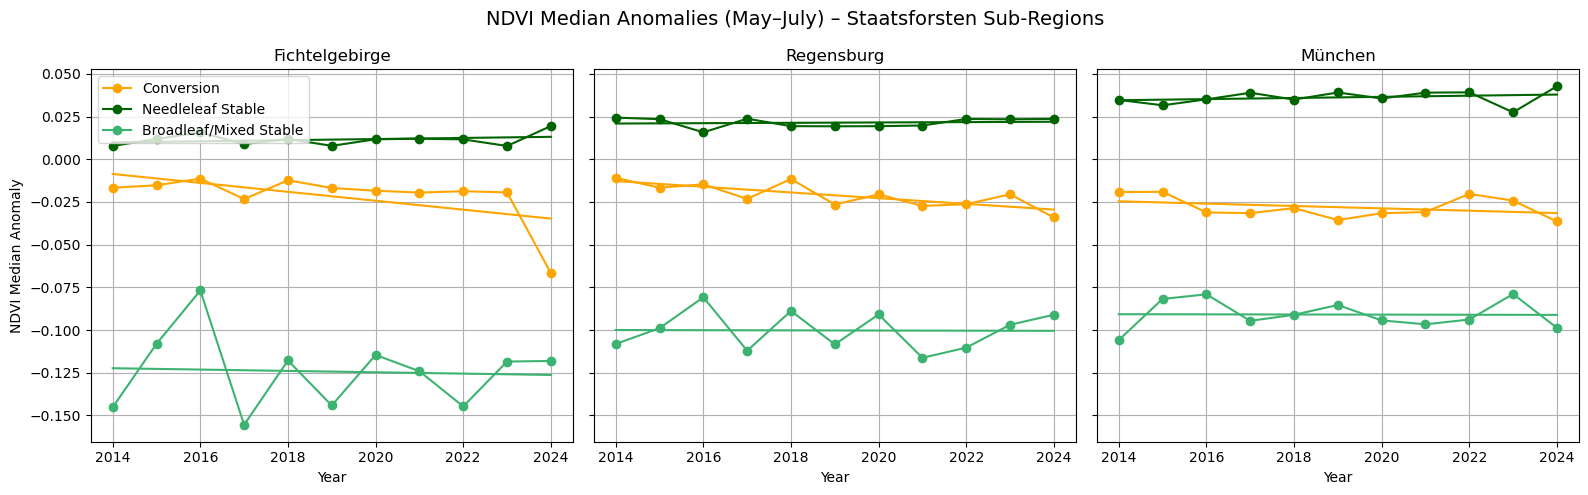

In [16]:
# NDVI winter season anomalies of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def ndvi_timeseries(region, klasse):
    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .filterBounds(region)
        .map(maskNDVI)
        .map(lambda img: img.updateMask(klasse)) 
        .map(lambda img: img.clip(region))       
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        val = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def ndvi_timeseries_total(region): # staatsforsten total hat keine klasse
    NDVI = (
        ee.ImageCollection("MODIS/061/MOD13Q1")
        .map(maskNDVI)
        .map(lambda img: img.clip(region))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ndvi_year = NDVI.filterDate(start, end).median().multiply(0.0001)

        val = (
            ndvi_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("NDVI")
            .getInfo()
        )

        values.append(val)

    return np.array(values)


def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (reg_name, region) in zip(axes, regions.items()):

    print("   ")
    print(f" REGION {reg_name}")

    
    # Timeseries
    conv  = ndvi_timeseries(region, conversion)
    need  = ndvi_timeseries(region, needle_stable)
    broad = ndvi_timeseries(region, broadleaf_stable)
    total = ndvi_timeseries_total(region)

    # Anomalies
    conv_delta  = conv  - total
    need_delta  = need  - total
    broad_delta = broad - total

    t = np.array(years)

    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
    }

    # Names
    anomaly_series = {
        "Conversion": conv_delta,
        "Needleleaf Stable": need_delta,
        "Broadleaf/Mixed Stable": broad_delta,
    }

    for name, vals in anomaly_series.items():

        stats = regression_stats(t, vals)
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print(f"\n{name}")
        print(f"Slope:        {stats['slope']:.6f}")
        print(f"Intercept:    {stats['intercept']:.6f}")
        print(f"R²:           {stats['r2']:.4f}")
        print(f"p-value:      {stats['p']:.6f}")
        print(f"Std. Error:   {stats['std_err']:.6f}")

    ax.set_title(reg_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("NDVI Median Anomaly")
axes[0].legend(loc="upper left")

fig.suptitle("NDVI Median Anomalies (May–July) – Staatsforsten Sub-Regions", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:

def maskET(image):
    qc = image.select("ET_QC")
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select("ET")



ET = ee.ImageCollection("MODIS/061/MOD16A2GF").filterBounds(bayern).map(maskET)
modis_proj = ET.first().projection()

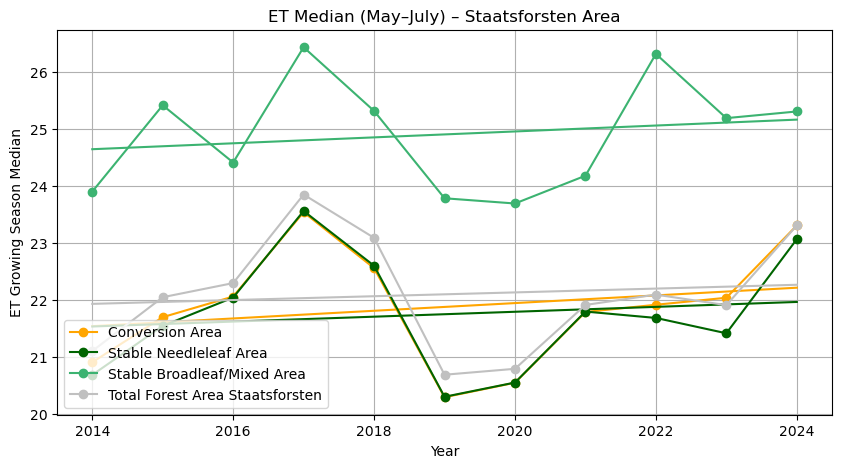


Conversion
Slope: 0.067341
Intercept: -114.082024
R²: 0.0472
p-value: 0.520947
Standard Error: 0.100823

Needleleaf Stable
Slope: 0.043016
Intercept: -65.097808
R²: 0.0192
p-value: 0.684840
Standard Error: 0.102594

Broadleaf/Mixed Stable
Slope: 0.051850
Intercept: -79.783099
R²: 0.0312
p-value: 0.603474
Standard Error: 0.096335

Total Forest Bavaria
Slope: 0.033436
Intercept: -45.406928
R²: 0.0120
p-value: 0.748896
Standard Error: 0.101298


In [35]:
### ET growing season medians of different forest structural classes


ET_conversion = ET.map(lambda img: img.updateMask(conversion))
ET_needle = ET.map(lambda img: img.updateMask(needle_stable))
ET_broadleaf = ET.map(lambda img: img.updateMask(broadleaf_stable))
ET_staatsforsten= ET.map(lambda img: img.clip(ROI))


years = list(range(2014, 2025))


def values(ET):
    ET_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ET_year = ET.filterDate(start, end).median().multiply(0.1)

        value = (
            ET_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("ET")
            .getInfo()
        )

        ET_values.append(value)
    return ET_values


conversion_values = values(ET_conversion)
needle_values = values(ET_needle)
broadleaf_values = values(ET_broadleaf)
staatsforsten_values = values(ET_staatsforsten)


# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(staatsforsten_values)


slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, staatsforsten_values, marker="o", color="silver", label="Total Forest Area Staatsforsten")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("ET Growing Season Median")
plt.title("ET Median (May–July) – Staatsforsten Area")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\n{name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")


Region Fichtelgebirge

Conversion
Slope:      -0.008800
Intercept:  39.335148
R²:         0.0006
p-value:    0.943816
Std Error:  0.121435

Needleleaf Stable
Slope:      -0.029076
Intercept:  80.411125
R²:         0.0061
p-value:    0.819060
Std Error:  0.123443

Broadleaf/Mixed Stable
Slope:      0.017311
Intercept:  -13.544137
R²:         0.0016
p-value:    0.908098
Std Error:  0.145805

Total Forest
Slope:      -0.021830
Intercept:  65.718848
R²:         0.0035
p-value:    0.862644
Std Error:  0.122622

Region Regensburg

Conversion
Slope:      0.299289
Intercept:  -582.949703
R²:         0.4126
p-value:    0.033068
Std Error:  0.119027

Needleleaf Stable
Slope:      0.200492
Intercept:  -383.616302
R²:         0.2564
p-value:    0.112002
Std Error:  0.113821

Broadleaf/Mixed Stable
Slope:      0.118045
Intercept:  -212.893360
R²:         0.1427
p-value:    0.252019
Std Error:  0.096440

Total Forest
Slope:      0.214794
Intercept:  -412.140287
R²:         0.3015
p-value:    0.0802

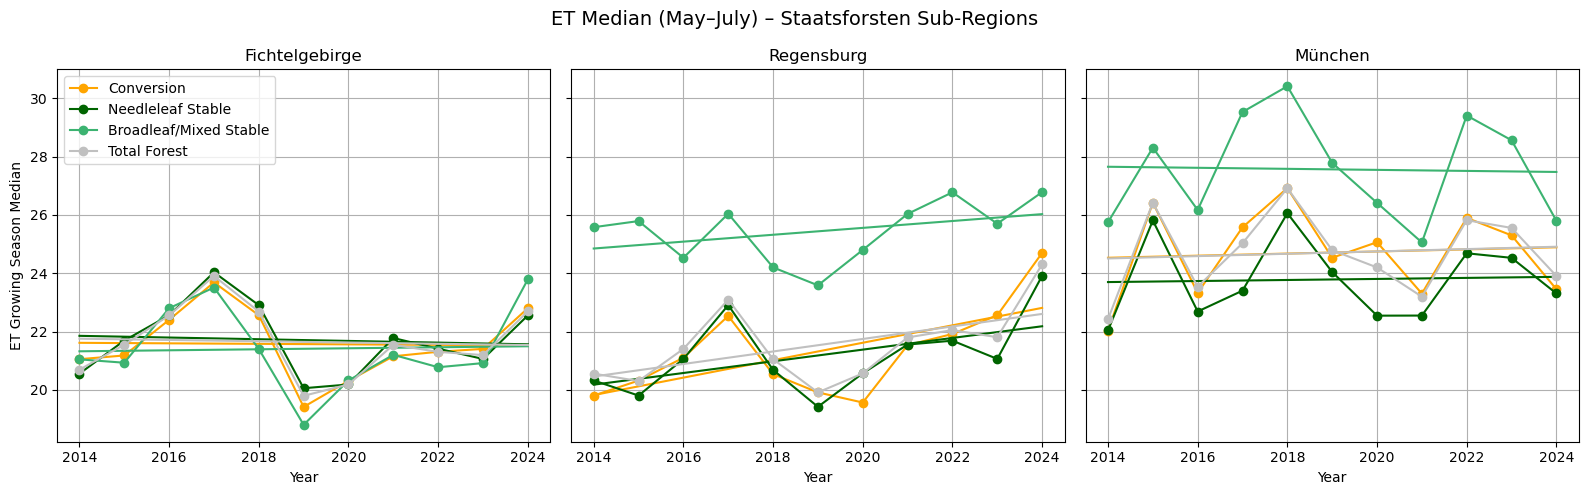

In [7]:
# ET growing season medians of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def ET_timeseries(region, klasse):
    ET = (
        ee.ImageCollection("MODIS/061/MOD16A2GF")
        .filterBounds(region)
        .map(maskET)
        .map(lambda img: img.updateMask(klasse))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ET_year = ET.filterDate(start, end).median().multiply(0.1)

        val = (
            ET_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("ET")
            .getInfo()
        )

        values.append(val)

    return np.array(values)

def ET_timeseries_total(region):
    ET = (
        ee.ImageCollection("MODIS/061/MOD16A2GF")
        .filterBounds(region)
        .map(maskET)
        .map(lambda img: img.clip(region))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ET_year = ET.filterDate(start, end).median().multiply(0.1)

        val = (
            ET_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("ET")
            .getInfo()
        )

        values.append(val)

    return np.array(values)


def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

forest_classes = [
    ("Conversion", conversion),
    ("Needleleaf Stable", needle_stable),
    ("Broadleaf/Mixed Stable", broadleaf_stable),
    ("Total Forest", None),  # eineger Fall, hat keine klasse
]

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (region_name, region) in zip(axes, regions.items()):

    print(f"\nRegion {region_name}")

    results = {}

    # Timeseries
    series = {
        "Conversion": ET_timeseries(region, conversion),
        "Needleleaf Stable": ET_timeseries(region, needle_stable),
        "Broadleaf/Mixed Stable": ET_timeseries(region, broadleaf_stable),
        "Total Forest": ET_timeseries_total(region),
    }

    t = np.array(years)

    # Regression and Plot
    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
        "Total Forest": "silver",
    }

    for name, vals in series.items():

        # Regression
        stats = regression_stats(t, vals)
        results[name] = stats

        # Trendline
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print(f"\n{name}")
        print(f"Slope:      {stats['slope']:.6f}")
        print(f"Intercept:  {stats['intercept']:.6f}")
        print(f"R²:         {stats['r2']:.4f}")
        print(f"p-value:    {stats['p']:.6f}")
        print(f"Std Error:  {stats['std_err']:.6f}")

    ax.set_title(region_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("ET Growing Season Median")
axes[0].legend(loc="upper left")

fig.suptitle("ET Median (May–July) – Staatsforsten Sub-Regions", fontsize=14)

plt.tight_layout()
plt.show()

 REGION Fichtelgebirge

Conversion
Slope:        0.013030
Intercept:    -26.383700
R²:           0.0282
p-value:      0.621767
Std. Error:   0.025508

Needleleaf Stable
Slope:        -0.007246
Intercept:    14.692277
R²:           0.0250
p-value:      0.642300
Std. Error:   0.015079

Broadleaf/Mixed Stable
Slope:        0.039141
Intercept:    -79.262985
R²:           0.0379
p-value:      0.566365
Std. Error:   0.065760
 REGION Regensburg

Conversion
Slope:        0.084495
Intercept:    -170.809416
R²:           0.3095
p-value:      0.075495
Std. Error:   0.042066

Needleleaf Stable
Slope:        -0.014302
Intercept:    28.523984
R²:           0.0597
p-value:      0.469162
Std. Error:   0.018926

Broadleaf/Mixed Stable
Slope:        -0.096750
Intercept:    199.246927
R²:           0.1164
p-value:      0.304527
Std. Error:   0.088857
 REGION München

Conversion
Slope:        -0.004291
Intercept:    8.664806
R²:           0.0013
p-value:      0.917493
Std. Error:   0.040273

Needleleaf St

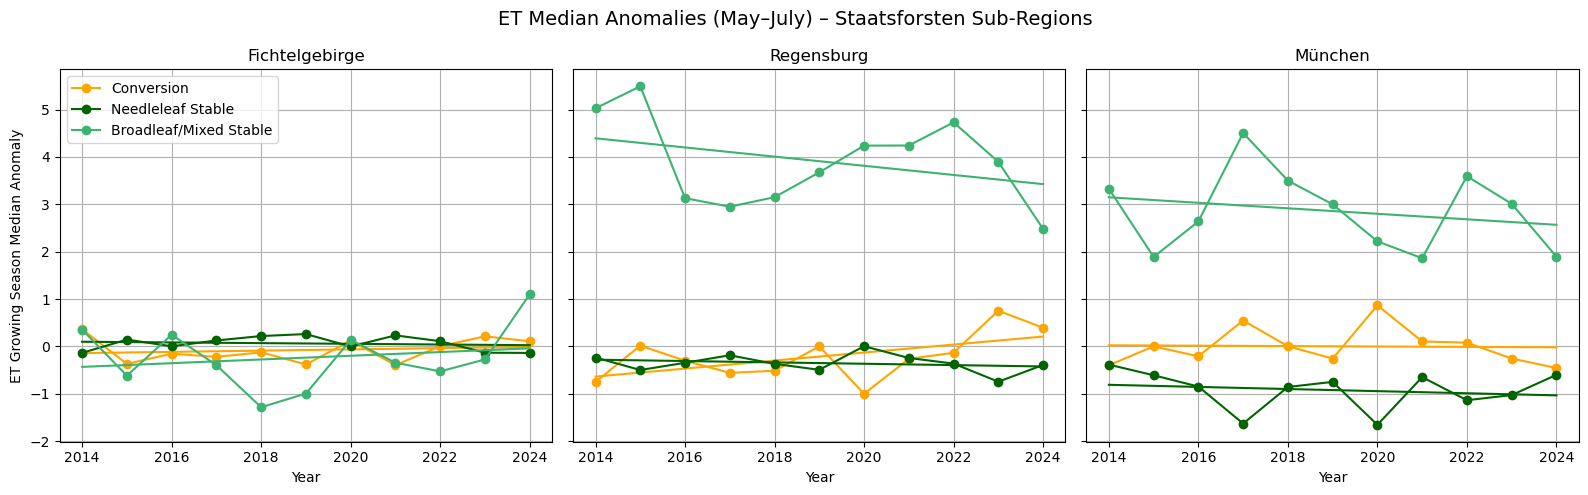

In [19]:
# ET growing season anomalies of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def ET_timeseries(region, klasse):
    ET = (
        ee.ImageCollection("MODIS/061/MOD16A2GF")
        .filterBounds(region)
        .map(maskET)
        .map(lambda img: img.updateMask(klasse))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ET_year = ET.filterDate(start, end).median().multiply(0.1)

        val = (
            ET_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("ET")
            .getInfo()
        )

        values.append(val)

    return np.array(values)

def ET_timeseries_total(region):
    ET = (
        ee.ImageCollection("MODIS/061/MOD16A2GF")
        .filterBounds(region)
        .map(maskET)
        .map(lambda img: img.clip(region))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ET_year = ET.filterDate(start, end).median().multiply(0.1)

        val = (
            ET_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("ET")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (reg_name, region) in zip(axes, regions.items()):
    
    print(f" REGION {reg_name}")

    
    # Timeseries
    conv  = ET_timeseries(region, conversion)
    need  = ET_timeseries(region, needle_stable)
    broad = ET_timeseries(region, broadleaf_stable)
    total = ET_timeseries_total(region)

    # Anomalies
    conv_delta  = conv  - total
    need_delta  = need  - total
    broad_delta = broad - total

    t = np.array(years)

    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
    }

    # Names
    anomaly_series = {
        "Conversion": conv_delta,
        "Needleleaf Stable": need_delta,
        "Broadleaf/Mixed Stable": broad_delta,
    }

    for name, vals in anomaly_series.items():

        stats = regression_stats(t, vals)
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print(f"\n{name}")
        print(f"Slope:        {stats['slope']:.6f}")
        print(f"Intercept:    {stats['intercept']:.6f}")
        print(f"R²:           {stats['r2']:.4f}")
        print(f"p-value:      {stats['p']:.6f}")
        print(f"Std. Error:   {stats['std_err']:.6f}")

    ax.set_title(reg_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("ET Growing Season Median Anomaly")
axes[0].legend(loc="upper left")

fig.suptitle("ET Median Anomalies (May–July) – Staatsforsten Sub-Regions", fontsize=14)

plt.tight_layout()
plt.show()

In [9]:
def maskALB(image):
    qc = image.select("BRDF_Albedo_Band_Mandatory_Quality_shortwave")
    mask = qc.bitwiseAnd(1).eq(0)
    return image.updateMask(mask).select("Albedo_BSA_shortwave")


ALB = ee.ImageCollection("MODIS/061/MCD43A3").filterBounds(ROI).map(maskALB)
modis_proj = ALB.first().projection()

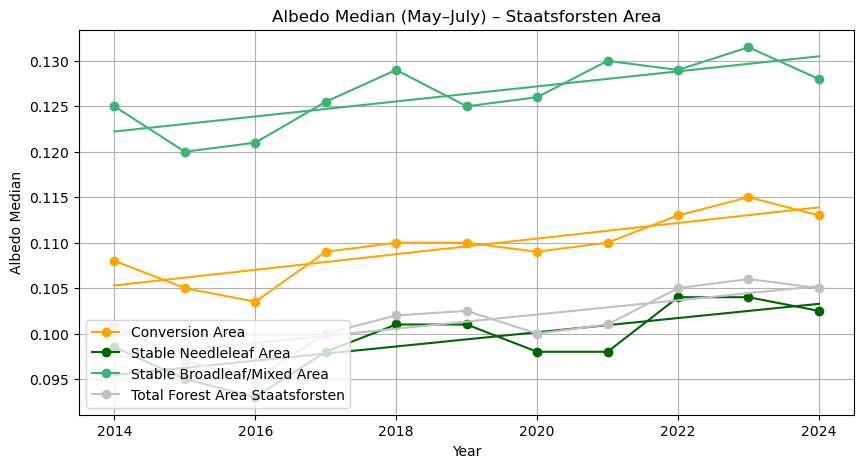


Conversion
Slope: 0.000859
Intercept: -1.624914
R²: 0.7096
p-value: 0.001137
Standard Error: 0.000183

Needleleaf Stable
Slope: 0.000782
Intercept: -1.479127
R²: 0.5420
p-value: 0.009780
Standard Error: 0.000240

Broadleaf/Mixed Stable
Slope: 0.000827
Intercept: -1.543900
R²: 0.5789
p-value: 0.006542
Standard Error: 0.000235

Total Forest Bavaria
Slope: 0.000782
Intercept: -1.477173
R²: 0.5943
p-value: 0.005478
Standard Error: 0.000215


In [21]:
### Albedo growing season medians of different forest structural classes


ALB_conversion = ALB.map(lambda img: img.updateMask(conversion))
ALB_needle = ALB.map(lambda img: img.updateMask(needle_stable))
ALB_broadleaf = ALB.map(lambda img: img.updateMask(broadleaf_stable))
ALB_staatsforsten= ALB.map(lambda img: img.clip(ROI))


years = list(range(2014, 2025))


def values(NDVI):
    ALB_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ALB_year = NDVI.filterDate(start, end).median().multiply(0.001)

        value = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        ALB_values.append(value)
    return ALB_values


conversion_values = values(ALB_conversion)
needle_values = values(ALB_needle)
broadleaf_values = values(ALB_broadleaf)
staatsforsten_values = values(ALB_staatsforsten)




# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(staatsforsten_values)


slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, staatsforsten_values, marker="o", color="silver", label="Total Forest Area Staatsforsten")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("Albedo Median")
plt.title("Albedo Median (May–July) – Staatsforsten Area")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\n{name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

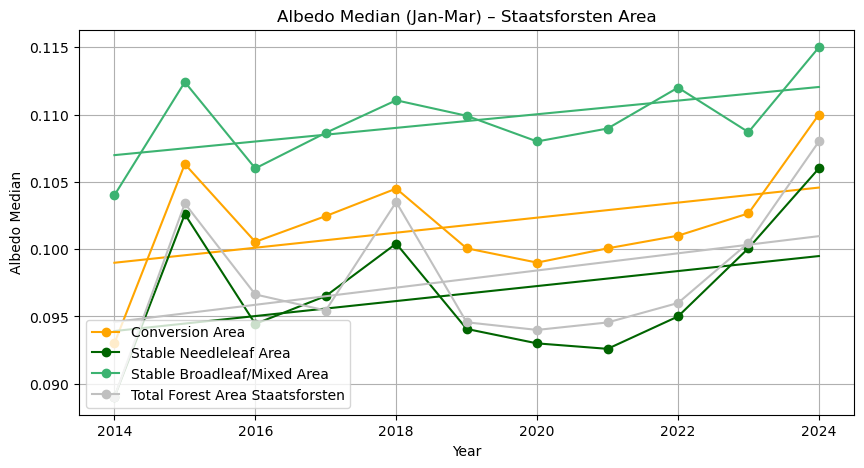


Conversion
Slope: 0.000558
Intercept: -1.025770
R²: 0.1809
p-value: 0.192203
Standard Error: 0.000396

Needleleaf Stable
Slope: 0.000557
Intercept: -1.028163
R²: 0.1360
p-value: 0.264491
Standard Error: 0.000468

Broadleaf/Mixed Stable
Slope: 0.000506
Intercept: -0.912829
R²: 0.3000
p-value: 0.081117
Standard Error: 0.000258

Total Forest Bavaria
Slope: 0.000638
Intercept: -1.189371
R²: 0.1500
p-value: 0.239190
Standard Error: 0.000506


In [39]:
### Albedo winter medians of different forest structural classes


ALB_conversion = ALB.map(lambda img: img.updateMask(conversion))
ALB_needle = ALB.map(lambda img: img.updateMask(needle_stable))
ALB_broadleaf = ALB.map(lambda img: img.updateMask(broadleaf_stable))
ALB_staatsforsten= ALB.map(lambda img: img.clip(ROI))


years = list(range(2014, 2025))


def values(NDVI):
    ALB_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ALB_year = NDVI.filterDate(start, end).median().multiply(0.001)

        value = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        ALB_values.append(value)
    return ALB_values


conversion_values = values(ALB_conversion)
needle_values = values(ALB_needle)
broadleaf_values = values(ALB_broadleaf)
staatsforsten_values = values(ALB_staatsforsten)




# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(staatsforsten_values)


slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, staatsforsten_values, marker="o", color="silver", label="Total Forest Area Staatsforsten")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("Albedo Median")
plt.title("Albedo Median (Jan-Mar) – Staatsforsten Area")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Stats
regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2

    print(f"\n{name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")


Region Fichtelgebirge

Conversion
Slope:      0.000536
Intercept:  -0.992873
R²:         0.2121
p-value:    0.154050
Std Error:  0.000345

Needleleaf Stable
Slope:      0.000491
Intercept:  -0.905873
R²:         0.2497
p-value:    0.117598
Std Error:  0.000284

Broadleaf/Mixed Stable
Slope:      0.000327
Intercept:  -0.547400
R²:         0.0876
p-value:    0.376947
Std Error:  0.000352

Total Forest
Slope:      0.000482
Intercept:  -0.885973
R²:         0.2247
p-value:    0.140735
Std Error:  0.000298

Region Regensburg

Conversion
Slope:      0.000995
Intercept:  -1.900823
R²:         0.6791
p-value:    0.001811
Std Error:  0.000228

Needleleaf Stable
Slope:      0.000855
Intercept:  -1.624691
R²:         0.6450
p-value:    0.002913
Std Error:  0.000211

Broadleaf/Mixed Stable
Slope:      0.000845
Intercept:  -1.579700
R²:         0.4731
p-value:    0.019310
Std Error:  0.000297

Total Forest
Slope:      0.000818
Intercept:  -1.546682
R²:         0.5550
p-value:    0.008520
Std Error

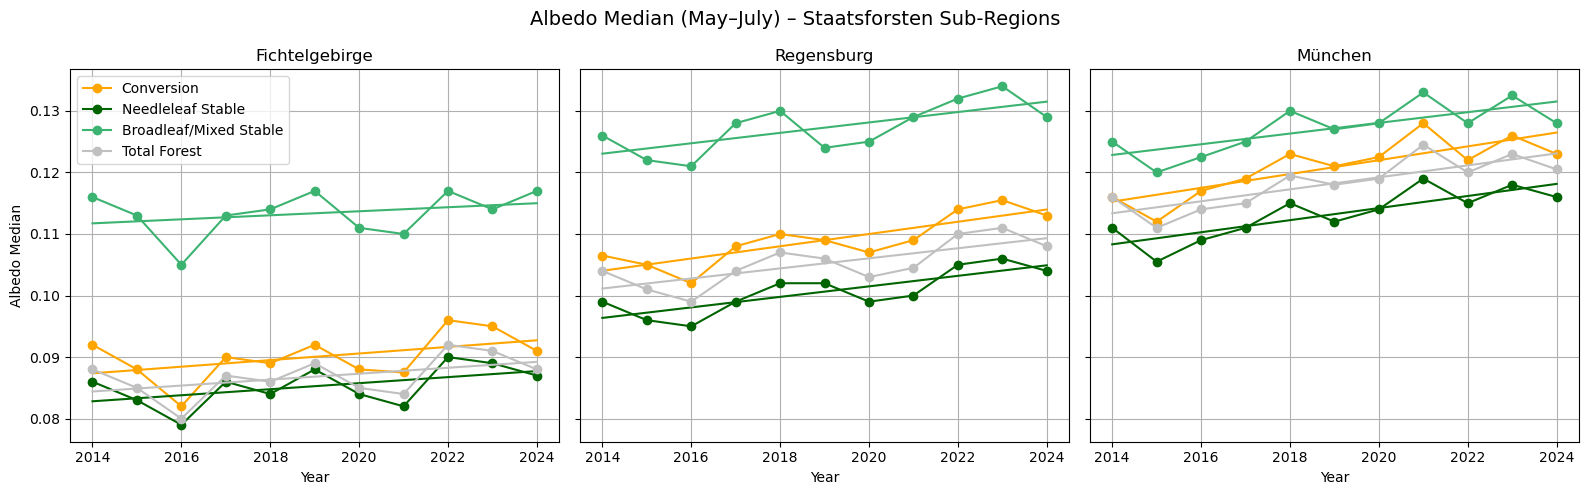

In [21]:
# Albedo growing season medians of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def ALB_timeseries(region, klasse):
    ALB = (
        ee.ImageCollection("MODIS/061/MCD43A3")
        .filterBounds(region)
        .map(maskALB)
        .map(lambda img: img.updateMask(klasse))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ALB_year = ALB.filterDate(start, end).median().multiply(0.001)

        val = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def ALB_timeseries_total(region):
    ALB = (
        ee.ImageCollection("MODIS/061/MCD43A3")
        .filterBounds(region)
        .map(maskALB)
        .map(lambda img: img.clip(ROI))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ALB_year = ALB.filterDate(start, end).median().multiply(0.001)

        val = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        values.append(val)

    return np.array(values)


def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

forest_classes = [
    ("Conversion", conversion),
    ("Needleleaf Stable", needle_stable),
    ("Broadleaf/Mixed Stable", broadleaf_stable),
    ("Total Forest", None),  # eineger Fall, hat keine klasse
]

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (region_name, region) in zip(axes, regions.items()):

    print(f"\nRegion {region_name}")

    results = {}

    # Timeseries
    series = {
        "Conversion": ALB_timeseries(region, conversion),
        "Needleleaf Stable": ALB_timeseries(region, needle_stable),
        "Broadleaf/Mixed Stable": ALB_timeseries(region, broadleaf_stable),
        "Total Forest": ALB_timeseries_total(region),
    }

    t = np.array(years)

    # Regression and Plot
    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
        "Total Forest": "silver",
    }

    for name, vals in series.items():

        # Regression
        stats = regression_stats(t, vals)
        results[name] = stats

        # Trendline
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print(f"\n{name}")
        print(f"Slope:      {stats['slope']:.6f}")
        print(f"Intercept:  {stats['intercept']:.6f}")
        print(f"R²:         {stats['r2']:.4f}")
        print(f"p-value:    {stats['p']:.6f}")
        print(f"Std Error:  {stats['std_err']:.6f}")

    ax.set_title(region_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("Albedo Median")
axes[0].legend(loc="upper left")

fig.suptitle("Albedo Median (May–July) – Staatsforsten Sub-Regions", fontsize=14)

plt.tight_layout()
plt.show()

  
 REGION Fichtelgebirge

Conversion
Slope:        0.000055
Intercept:    -0.106900
R²:           0.0889
p-value:      0.373199
Std. Error:   0.000058

Needleleaf Stable
Slope:        0.000009
Intercept:    -0.019900
R²:           0.0033
p-value:      0.866102
Std. Error:   0.000052

Broadleaf/Mixed Stable
Slope:        -0.000155
Intercept:    0.338573
R²:           0.0803
p-value:      0.398509
Std. Error:   0.000174
  
 REGION Regensburg

Conversion
Slope:        0.000177
Intercept:    -0.354141
R²:           0.5592
p-value:      0.008141
Std. Error:   0.000052

Needleleaf Stable
Slope:        0.000036
Intercept:    -0.078009
R²:           0.0604
p-value:      0.466429
Std. Error:   0.000048

Broadleaf/Mixed Stable
Slope:        0.000027
Intercept:    -0.033018
R²:           0.0027
p-value:      0.879253
Std. Error:   0.000174
  
 REGION München

Conversion
Slope:        0.000150
Intercept:    -0.300214
R²:           0.1702
p-value:      0.207389
Std. Error:   0.000110

Needleleaf S

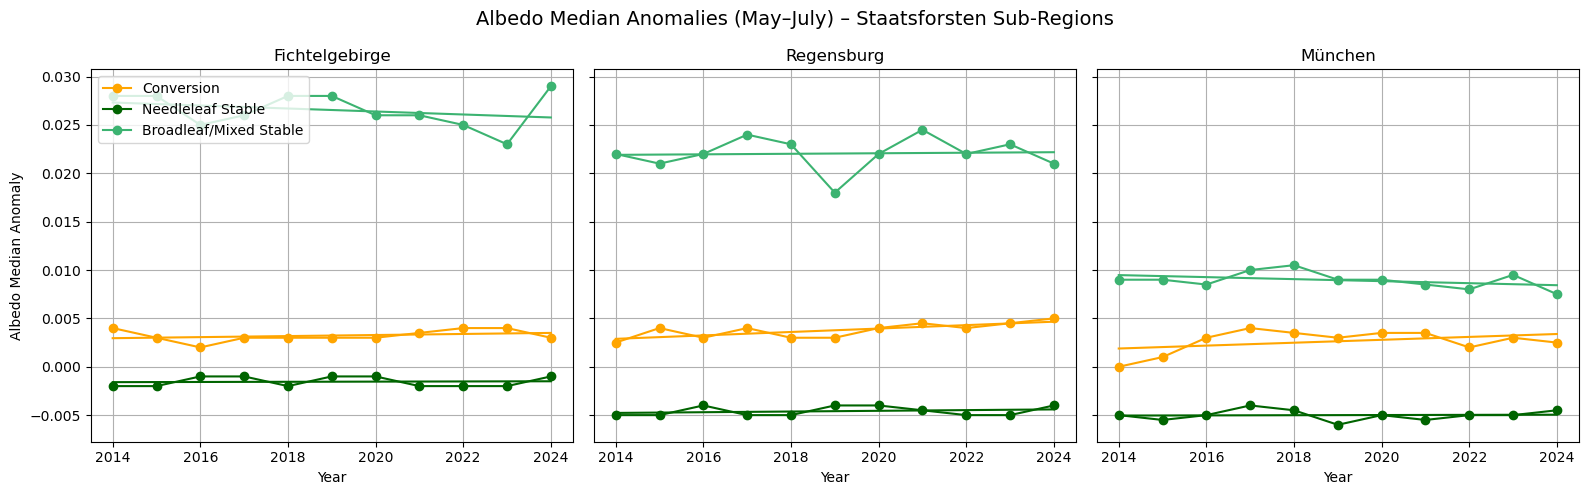

In [22]:
# Albedo growing season anomalies of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def ALB_timeseries(region, klasse):
    ALB = (
        ee.ImageCollection("MODIS/061/MCD43A3")
        .filterBounds(region)
        .map(maskALB)
        .map(lambda img: img.updateMask(klasse))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ALB_year = ALB.filterDate(start, end).median().multiply(0.001)

        val = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def ALB_timeseries_total(region):
    ALB = (
        ee.ImageCollection("MODIS/061/MCD43A3")
        .filterBounds(region)
        .map(maskALB)
        .map(lambda img: img.clip(ROI))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        ALB_year = ALB.filterDate(start, end).median().multiply(0.001)

        val = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (reg_name, region) in zip(axes, regions.items()):
    print("  ")
    print(f" REGION {reg_name}")

    
    # Timeseries
    conv  = ALB_timeseries(region, conversion)
    need  = ALB_timeseries(region, needle_stable)
    broad = ALB_timeseries(region, broadleaf_stable)
    total = ALB_timeseries_total(region)

    # Anomalies
    conv_delta  = conv  - total
    need_delta  = need  - total
    broad_delta = broad - total

    t = np.array(years)

    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
    }

    # Names
    anomaly_series = {
        "Conversion": conv_delta,
        "Needleleaf Stable": need_delta,
        "Broadleaf/Mixed Stable": broad_delta,
    }

    for name, vals in anomaly_series.items():

        stats = regression_stats(t, vals)
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print(f"\n{name}")
        print(f"Slope:        {stats['slope']:.6f}")
        print(f"Intercept:    {stats['intercept']:.6f}")
        print(f"R²:           {stats['r2']:.4f}")
        print(f"p-value:      {stats['p']:.6f}")
        print(f"Std. Error:   {stats['std_err']:.6f}")

    ax.set_title(reg_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("Albedo Median Anomaly")
axes[0].legend(loc="upper left")

fig.suptitle("Albedo Median Anomalies (May–July) – Staatsforsten Sub-Regions", fontsize=14)

plt.tight_layout()
plt.show()

  

Region Fichtelgebirge

Conversion
Slope:      -0.003558
Intercept:  7.306601
R²:         0.0434
p-value:    0.538730
Std Error:  0.005569

Needleleaf Stable
Slope:      -0.003836
Intercept:  7.852939
R²:         0.0808
p-value:    0.397029
Std Error:  0.004314

Broadleaf/Mixed Stable
Slope:      0.000586
Intercept:  -1.050473
R²:         0.0014
p-value:    0.913800
Std Error:  0.005264

Total Forest
Slope:      -0.002847
Intercept:  5.863580
R²:         0.0356
p-value:    0.578522
Std Error:  0.004940
  

Region Regensburg

Conversion
Slope:      0.001202
Intercept:  -2.325671
R²:         0.5781
p-value:    0.006600
Std Error:  0.000342

Needleleaf Stable
Slope:      0.001038
Intercept:  -2.000541
R²:         0.5266
p-value:    0.011479
Std Error:  0.000328

Broadleaf/Mixed Stable
Slope:      0.000828
Intercept:  -1.564762
R²:         0.4947
p-value:    0.015750
Std Error:  0.000279

Total Forest
Slope:      0.000934
Intercept:  -1.787172
R²:         0.5512
p-value:    0.008875
Std

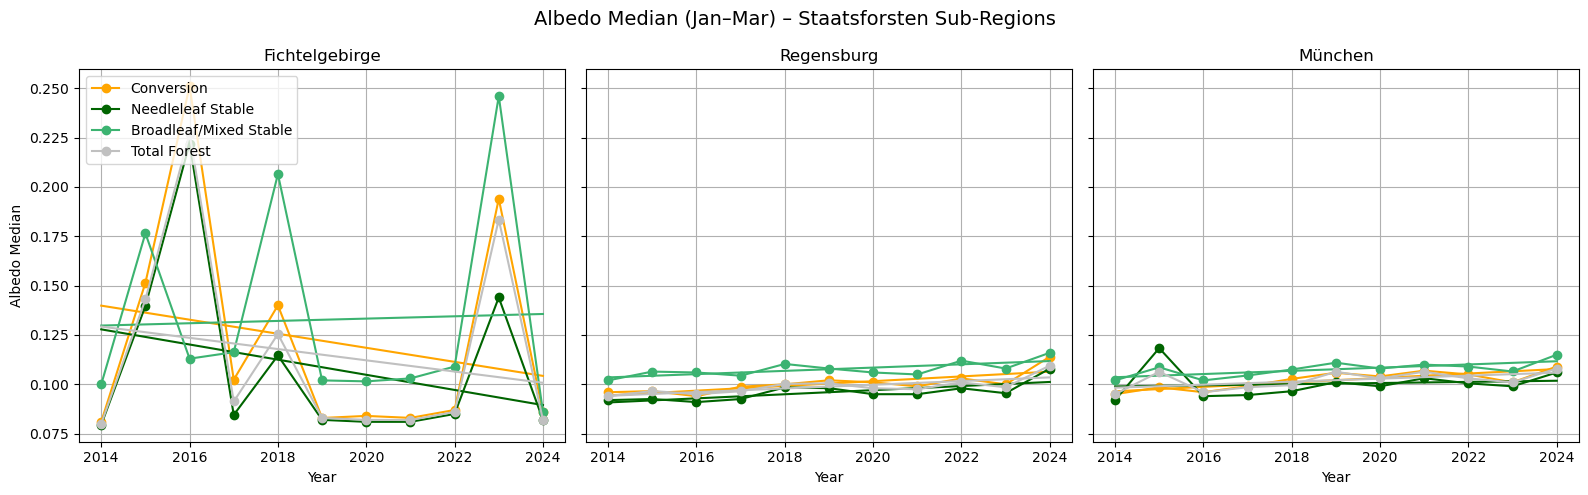

In [10]:
# Albedo winter season medians of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def ALB_timeseries(region, klasse):
    ALB = (
        ee.ImageCollection("MODIS/061/MCD43A3")
        .filterBounds(region)
        .map(maskALB)
        .map(lambda img: img.updateMask(klasse))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ALB_year = ALB.filterDate(start, end).median().multiply(0.001)

        val = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def ALB_timeseries_total(region):
    ALB = (
        ee.ImageCollection("MODIS/061/MCD43A3")
        .filterBounds(region)
        .map(maskALB)
        .map(lambda img: img.clip(ROI))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ALB_year = ALB.filterDate(start, end).median().multiply(0.001)

        val = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        values.append(val)

    return np.array(values)

def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

forest_classes = [
    ("Conversion", conversion),
    ("Needleleaf Stable", needle_stable),
    ("Broadleaf/Mixed Stable", broadleaf_stable),
    ("Total Forest", None),  # eineger Fall, hat keine klasse
]

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (region_name, region) in zip(axes, regions.items()):
    print("  ")

    print(f"\nRegion {region_name}")

    results = {}

    # Timeseries
    series = {
        "Conversion": ALB_timeseries(region, conversion),
        "Needleleaf Stable": ALB_timeseries(region, needle_stable),
        "Broadleaf/Mixed Stable": ALB_timeseries(region, broadleaf_stable),
        "Total Forest": ALB_timeseries_total(region),
    }

    t = np.array(years)

    # Regression and Plot
    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
        "Total Forest": "silver",
    }

    for name, vals in series.items():

        # Regression
        stats = regression_stats(t, vals)
        results[name] = stats

        # Trendline
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print(f"\n{name}")
        print(f"Slope:      {stats['slope']:.6f}")
        print(f"Intercept:  {stats['intercept']:.6f}")
        print(f"R²:         {stats['r2']:.4f}")
        print(f"p-value:    {stats['p']:.6f}")
        print(f"Std Error:  {stats['std_err']:.6f}")

    ax.set_title(region_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("Albedo Median")
axes[0].legend(loc="upper left")

fig.suptitle("Albedo Median (Jan–Mar) – Staatsforsten Sub-Regions", fontsize=14)

plt.tight_layout()
plt.show()

  
 REGION Fichtelgebirge
  

Conversion
Slope:        -0.000711
Intercept:    1.443021
R²:           0.0982
p-value:      0.348019
Std. Error:   0.000718
  

Needleleaf Stable
Slope:        -0.000988
Intercept:    1.989359
R²:           0.0814
p-value:      0.395187
Std. Error:   0.001107
  

Broadleaf/Mixed Stable
Slope:        0.003433
Intercept:    -6.914052
R²:           0.0542
p-value:      0.490696
Std. Error:   0.004779
  
 REGION Regensburg
  

Conversion
Slope:        0.000267
Intercept:    -0.538499
R²:           0.3269
p-value:      0.066090
Std. Error:   0.000128
  

Needleleaf Stable
Slope:        0.000104
Intercept:    -0.213369
R²:           0.1482
p-value:      0.242419
Std. Error:   0.000083
  

Broadleaf/Mixed Stable
Slope:        -0.000106
Intercept:    0.222410
R²:           0.0520
p-value:      0.500182
Std. Error:   0.000151
  
 REGION München
  

Conversion
Slope:        0.000365
Intercept:    -0.736132
R²:           0.1880
p-value:      0.182819
Std. Error:   0

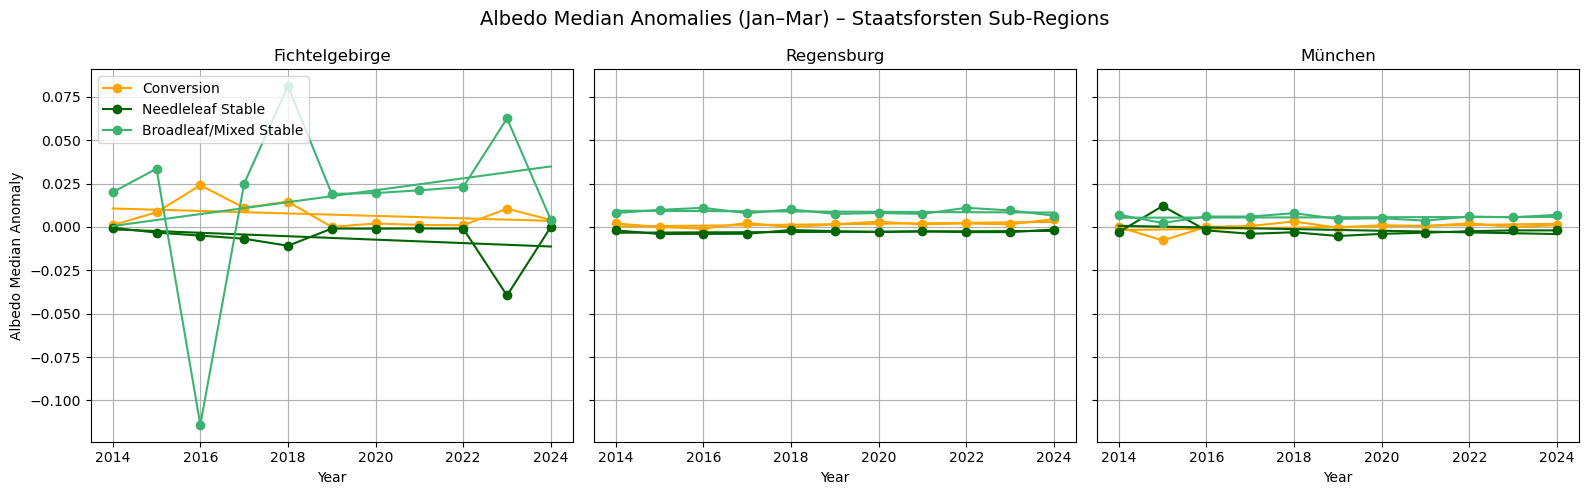

In [11]:
# Albedo winter season anomalies of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def ALB_timeseries(region, klasse):
    ALB = (
        ee.ImageCollection("MODIS/061/MCD43A3")
        .filterBounds(region)
        .map(maskALB)
        .map(lambda img: img.updateMask(klasse))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ALB_year = ALB.filterDate(start, end).median().multiply(0.001)

        val = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def ALB_timeseries_total(region):
    ALB = (
        ee.ImageCollection("MODIS/061/MCD43A3")
        .filterBounds(region)
        .map(maskALB)
        .map(lambda img: img.clip(ROI))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 1, 1)
        end = ee.Date.fromYMD(year, 4, 1)

        ALB_year = ALB.filterDate(start, end).median().multiply(0.001)

        val = (
            ALB_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("Albedo_BSA_shortwave")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (reg_name, region) in zip(axes, regions.items()):
    print("  ")

    print(f" REGION {reg_name}")

    
    # Timeseries
    conv  = ALB_timeseries(region, conversion)
    need  = ALB_timeseries(region, needle_stable)
    broad = ALB_timeseries(region, broadleaf_stable)
    total = ALB_timeseries_total(region)

    # Anomalies
    conv_delta  = conv  - total
    need_delta  = need  - total
    broad_delta = broad - total

    t = np.array(years)

    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
    }

    # Names
    anomaly_series = {
        "Conversion": conv_delta,
        "Needleleaf Stable": need_delta,
        "Broadleaf/Mixed Stable": broad_delta,
    }

    for name, vals in anomaly_series.items():

        stats = regression_stats(t, vals)
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print("  ")
        print(f"\n{name}")
        print(f"Slope:        {stats['slope']:.6f}")
        print(f"Intercept:    {stats['intercept']:.6f}")
        print(f"R²:           {stats['r2']:.4f}")
        print(f"p-value:      {stats['p']:.6f}")
        print(f"Std. Error:   {stats['std_err']:.6f}")

    ax.set_title(reg_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("Albedo Median Anomaly")
axes[0].legend(loc="upper left")

fig.suptitle("Albedo Median Anomalies (Jan–Mar) – Staatsforsten Sub-Regions", fontsize=14)

plt.tight_layout()
plt.show()

In [12]:
def maskLST(image):
    qc = image.select("QC_Day")
    mask = qc.bitwiseAnd(3).eq(0)
    return image.updateMask(mask).select("LST_Day_1km")


LST = ee.ImageCollection("MODIS/061/MOD11A1").filterBounds(bayern).map(maskLST)
modis_proj = LST.first().projection()

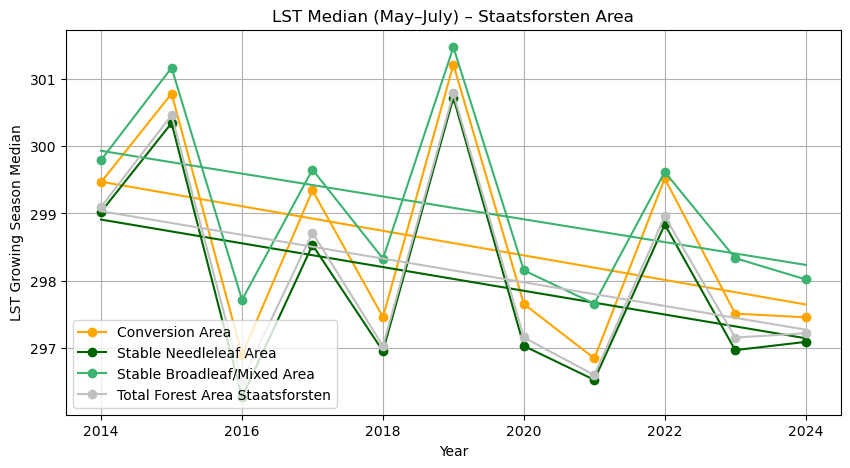


Conversion
Slope: -0.182065
Intercept: 666.149601
R²: 0.1503
p-value: 0.238833
Standard Error: 0.144321

Needleleaf Stable
Slope: -0.176020
Intercept: 653.411587
R²: 0.1425
p-value: 0.252435
Standard Error: 0.143940

Broadleaf/Mixed Stable
Slope: -0.169222
Intercept: 640.741677
R²: 0.1741
p-value: 0.201732
Standard Error: 0.122874

Total Forest Bavaria
Slope: -0.175752
Intercept: 652.997934
R²: 0.1461
p-value: 0.245949
Standard Error: 0.141612


In [14]:
### LST growing season medians of different forest structural classes



LST_conversion = LST.map(lambda img: img.updateMask(conversion))
LST_needle = LST.map(lambda img: img.updateMask(needle_stable))
LST_broadleaf = LST.map(lambda img: img.updateMask(broadleaf_stable))
LST_staatsforsten = LST.map(lambda img: img.clip(ROI))


years = list(range(2014, 2025))


def values(LST):
    LST_values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        LST_year = LST.filterDate(start, end).median().multiply(0.02)

        value = (
            LST_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=bayern.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("LST_Day_1km")
            .getInfo()
        )

        LST_values.append(value)
    return LST_values


conversion_values = values(LST_conversion)
needle_values = values(LST_needle)
broadleaf_values = values(LST_broadleaf)
staatsforsten_values = values(LST_staatsforsten)


# Regression
reg_years = np.array(years)
reg_conv = np.array(conversion_values)
reg_needle = np.array(needle_values)
reg_broadl = np.array(broadleaf_values)
reg_total = np.array(staatsforsten_values)


slope1, intercept1 = np.polyfit(reg_years, reg_conv, 1)
trend1 = slope1 * reg_years + intercept1

slope2, intercept2 = np.polyfit(reg_years, reg_needle, 1)
trend2 = slope2 * reg_years + intercept2

slope3, intercept3 = np.polyfit(reg_years, reg_broadl, 1)
trend3 = slope3 * reg_years + intercept3

slope4, intercept4 = np.polyfit(reg_years, reg_total, 1)
trend4 = slope4 * reg_years + intercept4

# Plot
plt.figure(figsize=(10, 5))
plt.plot(years, conversion_values, marker="o", color="orange", label="Conversion Area")
plt.plot(reg_years, trend1, "-", color="orange")
plt.plot(years, needle_values, marker="o", color="darkgreen", label="Stable Needleleaf Area")
plt.plot(reg_years, trend2, "-", color="darkgreen")
plt.plot(years, broadleaf_values, marker="o", color="mediumseagreen", label="Stable Broadleaf/Mixed Area")
plt.plot(reg_years, trend3, "-", color="mediumseagreen")
plt.plot(years, staatsforsten_values, marker="o", color="silver", label="Total Forest Area Staatsforsten")
plt.plot(reg_years, trend4, "-", color="silver")
plt.xlabel("Year")
plt.ylabel("LST Growing Season Median")
plt.title("LST Median (May–July) – Staatsforsten Area")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

regression_values = [
    ("Conversion", reg_conv),
    ("Needleleaf Stable", reg_needle),
    ("Broadleaf/Mixed Stable", reg_broadl),
    ("Total Forest Bavaria", reg_total)
]

for name, vals in regression_values:
    slope, intercept, r, p, std_err = linregress(reg_years, vals)
    r2 = r**2
   
    print(f"\n{name}")
    print(f"Slope: {slope:.6f}")
    print(f"Intercept: {intercept:.6f}")
    print(f"R²: {r2:.4f}")
    print(f"p-value: {p:.6f}")
    print(f"Standard Error: {std_err:.6f}")

  

Region Fichtelgebirge

Conversion
Slope:      -0.200825
Intercept:  702.360969
R²:         0.1305
p-value:    0.275054
Std Error:  0.172800

Needleleaf Stable
Slope:      -0.226580
Intercept:  753.981102
R²:         0.1656
p-value:    0.214170
Std Error:  0.169525

Broadleaf/Mixed Stable
Slope:      -0.240000
Intercept:  782.276364
R²:         0.1787
p-value:    0.195150
Std Error:  0.171480

Total Forest
Slope:      -0.218279
Intercept:  737.360634
R²:         0.1563
p-value:    0.228737
Std Error:  0.169023
  

Region Regensburg

Conversion
Slope:      -0.146079
Intercept:  594.048952
R²:         0.1062
p-value:    0.328095
Std Error:  0.141268

Needleleaf Stable
Slope:      -0.142210
Intercept:  585.960158
R²:         0.0987
p-value:    0.346877
Std Error:  0.143282

Broadleaf/Mixed Stable
Slope:      -0.128057
Intercept:  557.607760
R²:         0.0953
p-value:    0.355686
Std Error:  0.131527

Total Forest
Slope:      -0.133286
Intercept:  568.081676
R²:         0.0930
p-value:

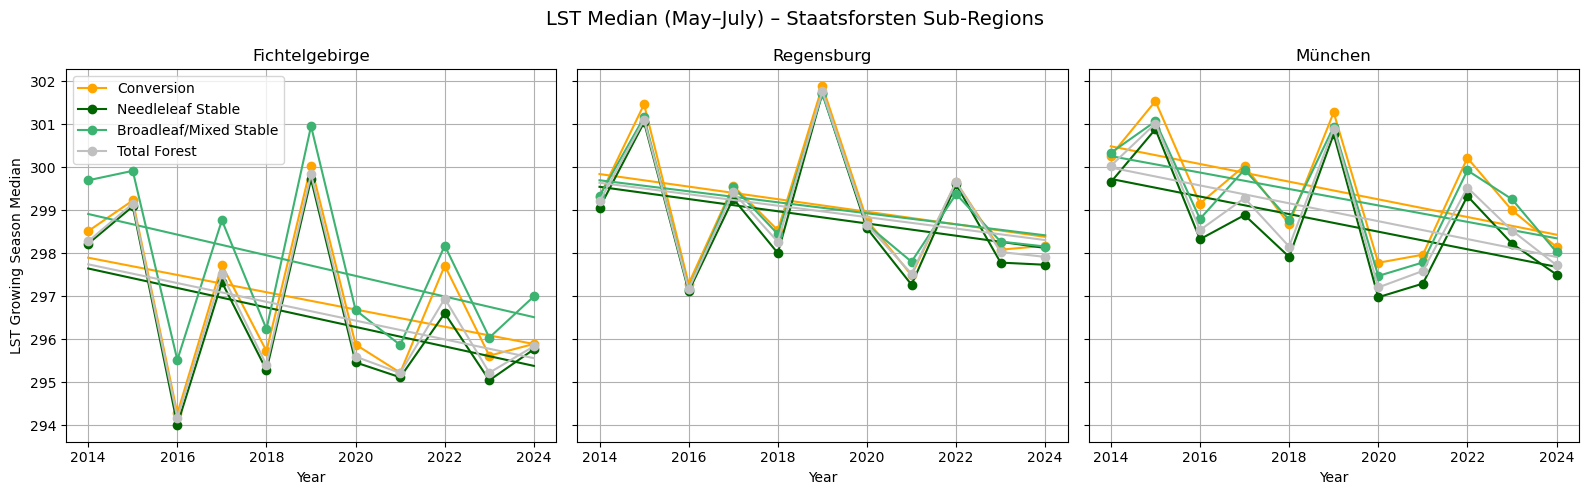

In [13]:
# LST growing season medians of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def LST_timeseries(region, klasse):
    LST = (
        ee.ImageCollection("MODIS/061/MOD11A1")
        .filterBounds(region)
        .map(maskLST)
        .map(lambda img: img.updateMask(klasse))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        LST_year = LST.filterDate(start, end).median().multiply(0.02)

        val = (
            LST_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("LST_Day_1km")
            .getInfo()
        )

        values.append(val)

    return np.array(values)


def LST_timeseries_total(region):
    LST = (
        ee.ImageCollection("MODIS/061/MOD11A1")
        .filterBounds(region)
        .map(maskLST)
        .map(lambda img: img.clip(ROI))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        LST_year = LST.filterDate(start, end).median().multiply(0.02)

        val = (
            LST_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("LST_Day_1km")
            .getInfo()
        )

        values.append(val)

    return np.array(values)


def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

forest_classes = [
    ("Conversion", conversion),
    ("Needleleaf Stable", needle_stable),
    ("Broadleaf/Mixed Stable", broadleaf_stable),
    ("Total Forest", None),  # eineger Fall, hat keine klasse
]

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (region_name, region) in zip(axes, regions.items()):
    print("  ")

    print(f"\nRegion {region_name}")

    results = {}

    # Timeseries
    series = {
        "Conversion": LST_timeseries(region, conversion),
        "Needleleaf Stable": LST_timeseries(region, needle_stable),
        "Broadleaf/Mixed Stable": LST_timeseries(region, broadleaf_stable),
        "Total Forest": LST_timeseries_total(region),
    }

    t = np.array(years)

    # Regression and Plot
    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
        "Total Forest": "silver",
    }

    for name, vals in series.items():

        # Regression
        stats = regression_stats(t, vals)
        results[name] = stats

        # Trendline
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print(f"\n{name}")
        print(f"Slope:      {stats['slope']:.6f}")
        print(f"Intercept:  {stats['intercept']:.6f}")
        print(f"R²:         {stats['r2']:.4f}")
        print(f"p-value:    {stats['p']:.6f}")
        print(f"Std Error:  {stats['std_err']:.6f}")

    ax.set_title(region_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("LST Growing Season Median")
axes[0].legend(loc="upper left")

fig.suptitle("LST Median (May–July) – Staatsforsten Sub-Regions", fontsize=14)

plt.tight_layout()
plt.show()

  
 REGION Fichtelgebirge
  

Conversion
Slope:        0.017455
Intercept:    -34.999664
R²:           0.0747
p-value:      0.416074
Std. Error:   0.020476
  

Needleleaf Stable
Slope:        -0.008301
Intercept:    16.620469
R²:           0.1151
p-value:      0.307449
Std. Error:   0.007673
  

Broadleaf/Mixed Stable
Slope:        -0.021721
Intercept:    44.915730
R²:           0.0791
p-value:      0.402130
Std. Error:   0.024703
  
 REGION Regensburg
  

Conversion
Slope:        -0.012793
Intercept:    25.967275
R²:           0.1266
p-value:      0.282850
Std. Error:   0.011200
  

Needleleaf Stable
Slope:        -0.008924
Intercept:    17.878482
R²:           0.1125
p-value:      0.313201
Std. Error:   0.008353
  

Broadleaf/Mixed Stable
Slope:        0.005229
Intercept:    -10.473916
R²:           0.0113
p-value:      0.755261
Std. Error:   0.016271
  
 REGION München
  

Conversion
Slope:        0.002325
Intercept:    -4.187408
R²:           0.0027
p-value:      0.879952
Std. Erro

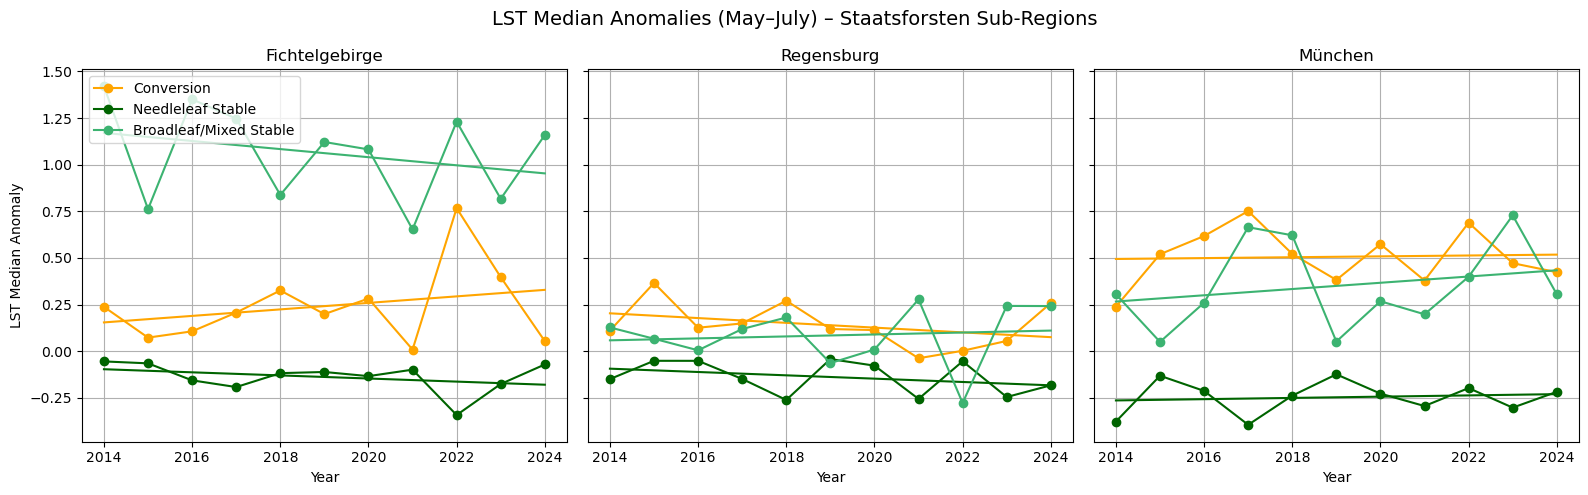

In [14]:
# LST growing sesason anomalies of different forest structural classes - Region split

regions = {"Fichtelgebirge": FGB, "Regensburg": RGB, "München": MUC}

years = list(range(2014, 2025))



def LST_timeseries(region, klasse):
    LST = (
        ee.ImageCollection("MODIS/061/MOD11A1")
        .filterBounds(region)
        .map(maskLST)
        .map(lambda img: img.updateMask(klasse))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        LST_year = LST.filterDate(start, end).median().multiply(0.02)

        val = (
            LST_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("LST_Day_1km")
            .getInfo()
        )

        values.append(val)

    return np.array(values)


def LST_timeseries_total(region):
    LST = (
        ee.ImageCollection("MODIS/061/MOD11A1")
        .filterBounds(region)
        .map(maskLST)
        .map(lambda img: img.clip(ROI))
    )

    values = []

    for year in years:
        start = ee.Date.fromYMD(year, 5, 1)
        end = ee.Date.fromYMD(year, 8, 1)

        LST_year = LST.filterDate(start, end).median().multiply(0.02)

        val = (
            LST_year.reduceRegion(
                reducer=ee.Reducer.median(),
                geometry=region.geometry(),
                scale = modis_proj.nominalScale(),
                maxPixels=1e13,
            )
            .get("LST_Day_1km")
            .getInfo()
        )

        values.append(val)

    return np.array(values)



def regression_stats(years, values):
    slope, intercept, r, p, std_err = linregress(years, values)
    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2,
        "p": p,
        "std_err": std_err
    }

# Plot
fig, axes = plt.subplots(1, len(regions), figsize=(16, 5), sharey=True)

for ax, (reg_name, region) in zip(axes, regions.items()):

    print("  ")
    print(f" REGION {reg_name}")

    
    # Timeseries
    conv  = LST_timeseries(region, conversion)
    need  = LST_timeseries(region, needle_stable)
    broad = LST_timeseries(region, broadleaf_stable)
    total = LST_timeseries_total(region)

    # Anomalies
    conv_delta  = conv  - total
    need_delta  = need  - total
    broad_delta = broad - total

    t = np.array(years)

    colors = {
        "Conversion": "orange",
        "Needleleaf Stable": "darkgreen",
        "Broadleaf/Mixed Stable": "mediumseagreen",
    }

    # Names
    anomaly_series = {
        "Conversion": conv_delta,
        "Needleleaf Stable": need_delta,
        "Broadleaf/Mixed Stable": broad_delta,
    }

    for name, vals in anomaly_series.items():

        stats = regression_stats(t, vals)
        trend = stats["slope"] * t + stats["intercept"]

        # Plot
        ax.plot(years, vals, "o-", color=colors[name], label=name)
        ax.plot(years, trend, "-", color=colors[name])

        # Statistics
        print("  ")
        print(f"\n{name}")
        print(f"Slope:        {stats['slope']:.6f}")
        print(f"Intercept:    {stats['intercept']:.6f}")
        print(f"R²:           {stats['r2']:.4f}")
        print(f"p-value:      {stats['p']:.6f}")
        print(f"Std. Error:   {stats['std_err']:.6f}")

    ax.set_title(reg_name)
    ax.set_xlabel("Year")
    ax.grid(True)

axes[0].set_ylabel("LST Median Anomaly")
axes[0].legend(loc="upper left")

fig.suptitle("LST Median Anomalies (May–July) – Staatsforsten Sub-Regions", fontsize=14)

plt.tight_layout()
plt.show()